# Chapter 08: Regularization and Batching (Overfitting, Dropout, & Mini-Batch Gradient Descent)
<a href="https://colab.research.google.com/github/SatrioArjunaPutra/GrokkingDeepLearning/blob/main/Chapter%2008%20-%20Regularization%20and%20Batching/08_regularization_batching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Course:** Tugas 2 - Enrichment Deep Learning Class  
**Student Name:** Satrio Arjuna Putra  
**Student ID (NIM):** 101032330178  
**Class:** TK-47-05  
**Primary Reference:** *Grokking Deep Learning* by Andrew W. Trask (Manning Publications)

---

## Chapter Objectives
In this chapter, we master the two most essential practical pillars of real-world deep neural network training:
1. **The Overfitting Dilemma:** Why deep networks with thousands of parameters memorize training data without learning generalizable concepts.
2. **Dropout Regularization:** Andrew Trask's intuition on why randomly turning off 50% of hidden neurons forces features to un-correlate and prevents co-adaptation.
3. **Inverted Dropout Implementation:** Implementing dropout masks (`np.random.randint`) and proper scaling ($1/p$) in pure NumPy.
4. **Batching Strategies:** Comparing **Stochastic Gradient Descent (SGD)**, **Full-Batch Descent**, and **Mini-Batch Gradient Descent** in terms of compute speed, gradient variance, and SIMD hardware efficiency.

## 1. Concept & Theoretical Intuition

### 1.1 Overfitting: Memorization vs. Generalization
A neural network with many weights has immense representational flexibility. If left unchecked, it can easily memorize idiosyncrasies and noise in the training set:
$$\mathcal{L}_{\text{train}} \to 0, \quad \text{while } \mathcal{L}_{\text{test}} \uparrow \text{ (diverges!)}$$
This widening performance gap is **overfitting**. A model that merely memorizes cannot generalize to unseen real-world data.

---

### 1.2 Andrew Trask's Intuition on Dropout
> *"Imagine you are in a trivia contest with friends. If one friend knows everything, the others become lazy and never study. But if the team captain randomly sends half the team out of the room during practice rounds, everyone is forced to learn!"*

Dropout randomly mutes hidden nodes with probability $p = 0.5$ during every forward pass:
* **Prevents Co-adaptation:** No hidden neuron can rely on another specific neuron being active. Every neuron must learn universally useful, self-contained features.
* **Implicit Ensemble:** A network with $H$ hidden nodes trained with dropout is mathematically equivalent to training an ensemble of $2^H$ distinct smaller subnetworks with shared weights!

#### Mathematical Formulation (Inverted Dropout):
During training, for hidden layer $\mathbf{a}_1$:
$$\mathbf{m} \sim \text{Bernoulli}(1 - p), \quad m_j \in \{0, 1\}$$
$$\mathbf{a}_{1,\text{drop}} = \frac{\mathbf{a}_1 \odot \mathbf{m}}{1 - p}$$
Scaling by $\frac{1}{1 - p}$ (or $2.0$ when $p = 0.5$) maintains the expected value of activations:
$$\mathbb{E}[\mathbf{a}_{1,\text{drop}}] = \mathbf{a}_1$$
During testing/evaluation, dropout is **turned off completely** ($\mathbf{a}_{1,\text{test}} = \mathbf{a}_1$).

---

### 1.3 Batching: SGD vs. Full-Batch vs. Mini-Batch

| Metric | Stochastic GD (SGD) | Full-Batch GD | Mini-Batch GD (Best of Both) |
| :--- | :--- | :--- | :--- |
| **Batch Size ($B$)** | $B = 1$ | $B = N$ (All data) | $1 < B < N$ (e.g. 64, 100) |
| **Updates per Epoch** | $N$ updates | $1$ update | $N / B$ updates |
| **Gradient Quality** | High variance, noisy | Exact gradient, smooth | Moderately smooth estimate |
| **Hardware Efficiency** | Poor (cannot use SIMD matrix BLAS) | High memory consumption | Maximum GPU/CPU throughput |
| **Convergence Behavior** | Bounces around, escapes saddles | Prone to getting stuck in local minima | Rapid, stable convergence |

In Mini-Batch GD, we slice input blocks $\mathbf{X}_{\text{batch}} \in \mathbb{R}^{B \times D}$ and compute vectorized matrix products:
$$\mathbf{Z}_1 = \mathbf{X}_{\text{batch}} \mathbf{W}_{01}, \quad \boldsymbol{\delta}_2 = \frac{1}{B} (\mathbf{\hat{Y}}_{\text{batch}} - \mathbf{Y}_{\text{batch}})$$

## 2. Scratch Implementation: Dropout & Mini-Batching

We construct two complete networks from scratch:
1. **Network A (Baseline):** Standard 2-layer network without regularization.
2. **Network B (Regularized):** 2-layer network with 50% Inverted Dropout trained via Mini-Batch Gradient Descent ($B = 100$).

In [1]:
import numpy as np
import os
import urllib.request

# Load MNIST data
def load_mnist():
    dataset_path = 'mnist.npz'
    if not os.path.exists(dataset_path):
        url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
        urllib.request.urlretrieve(url, dataset_path)
    with np.load(dataset_path) as data:
        x_train, y_train = data['x_train'], data['y_train']
        x_test, y_test = data['x_test'], data['y_test']
    return (x_train, y_train), (x_test, y_test)

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_mnist()

# Use 2000 train samples and 500 test samples for clear overfitting illustration
N_TRAIN = 2000
N_TEST = 500

images = x_train_raw[:N_TRAIN].reshape(N_TRAIN, 784) / 255.0
labels = y_train_raw[:N_TRAIN]

test_images = x_test_raw[:N_TEST].reshape(N_TEST, 784) / 255.0
test_labels = y_test_raw[:N_TEST]

# One-hot encode targets
targets = np.zeros((N_TRAIN, 10))
for i, l in enumerate(labels):
    targets[i, l] = 1.0

test_targets = np.zeros((N_TEST, 10))
for i, l in enumerate(test_labels):
    test_targets[i, l] = 1.0

print(f"Data initialized: {N_TRAIN} train samples, {N_TEST} test samples.")

Data initialized: 2000 train samples, 500 test samples.


In [2]:
def relu(x):
    return (x > 0) * x

def relu2deriv(x):
    return (x > 0) * 1.0

HIDDEN_DIM = 100
ALPHA = 0.005
EPOCHS = 30
BATCH_SIZE = 100

# ----------------- 1. Train Baseline Network (No Dropout) -----------------
print("=== Training Baseline Network (No Dropout) ===")
np.random.seed(42)
w_01_base = 0.1 * (np.random.random((784, HIDDEN_DIM)) * 2 - 1)
w_12_base = 0.1 * (np.random.random((HIDDEN_DIM, 10)) * 2 - 1)

base_train_loss, base_test_loss = [], []
base_train_acc, base_test_acc = [], []

for epoch in range(EPOCHS):
    train_loss = 0.0
    correct = 0
    # Mini-batch loop
    for b in range(0, N_TRAIN, BATCH_SIZE):
        bx = images[b:b+BATCH_SIZE]
        by = targets[b:b+BATCH_SIZE]
        
        # Forward pass (no dropout)
        l1 = relu(bx.dot(w_01_base))
        l2 = l1.dot(w_12_base)
        
        train_loss += np.sum((l2 - by) ** 2)
        correct += np.sum(np.argmax(l2, axis=1) == np.argmax(by, axis=1))
        
        # Backward pass
        l2_delta = (l2 - by) / BATCH_SIZE
        l1_delta = l2_delta.dot(w_12_base.T) * relu2deriv(l1)
        
        w_12_base -= ALPHA * l1.T.dot(l2_delta)
        w_01_base -= ALPHA * bx.T.dot(l1_delta)
        
    # Evaluate test set
    test_l1 = relu(test_images.dot(w_01_base))
    test_l2 = test_l1.dot(w_12_base)
    t_loss = np.sum((test_l2 - test_targets) ** 2) / N_TEST
    t_acc = np.mean(np.argmax(test_l2, axis=1) == test_labels) * 100.0
    
    base_train_loss.append(train_loss / N_TRAIN)
    base_test_loss.append(t_loss)
    base_train_acc.append((correct / N_TRAIN) * 100.0)
    base_test_acc.append(t_acc)

print(f"Baseline Final - Train Acc: {base_train_acc[-1]:.2f}% | Test Acc: {base_test_acc[-1]:.2f}%")

# ----------------- 2. Train Network with Inverted Dropout -----------------
print("\n=== Training Network with Inverted Dropout (p=0.5) ===")
np.random.seed(42)
w_01_drop = 0.1 * (np.random.random((784, HIDDEN_DIM)) * 2 - 1)
w_12_drop = 0.1 * (np.random.random((HIDDEN_DIM, 10)) * 2 - 1)

drop_train_loss, drop_test_loss = [], []
drop_train_acc, drop_test_acc = [], []

for epoch in range(EPOCHS):
    train_loss = 0.0
    correct = 0
    for b in range(0, N_TRAIN, BATCH_SIZE):
        bx = images[b:b+BATCH_SIZE]
        by = targets[b:b+BATCH_SIZE]
        
        # Forward pass WITH Inverted Dropout
        l1 = relu(bx.dot(w_01_drop))
        mask = np.random.randint(2, size=l1.shape) # 50% binary mask
        l1_masked = l1 * mask * 2.0                 # Inverted scaling (* 2)
        l2 = l1_masked.dot(w_12_drop)
        
        train_loss += np.sum((l2 - by) ** 2)
        correct += np.sum(np.argmax(l2, axis=1) == np.argmax(by, axis=1))
        
        # Backward pass through dropout mask
        l2_delta = (l2 - by) / BATCH_SIZE
        l1_delta = l2_delta.dot(w_12_drop.T) * relu2deriv(l1) * mask * 2.0
        
        w_12_drop -= ALPHA * l1_masked.T.dot(l2_delta)
        w_01_drop -= ALPHA * bx.T.dot(l1_delta)
        
    # Evaluate test set WITHOUT Dropout
    test_l1 = relu(test_images.dot(w_01_drop))
    test_l2 = test_l1.dot(w_12_drop)
    t_loss = np.sum((test_l2 - test_targets) ** 2) / N_TEST
    t_acc = np.mean(np.argmax(test_l2, axis=1) == test_labels) * 100.0
    
    drop_train_loss.append(train_loss / N_TRAIN)
    drop_test_loss.append(t_loss)
    drop_train_acc.append((correct / N_TRAIN) * 100.0)
    drop_test_acc.append(t_acc)

print(f"Dropout Final  - Train Acc: {drop_train_acc[-1]:.2f}% | Test Acc: {drop_test_acc[-1]:.2f}%")

=== Training Baseline Network (No Dropout) ===


Baseline Final - Train Acc: 76.85% | Test Acc: 71.20%

=== Training Network with Inverted Dropout (p=0.5) ===


Dropout Final  - Train Acc: 53.75% | Test Acc: 63.80%


## 3. Visualizations & Analytical Plots

We now plot two critical analytical graphs:
1. **Generalization Gap (Loss Curves):** Comparing the train vs. test loss trajectory for both networks to visualize overfitting mitigation.
2. **Test Accuracy Progression:** Demonstrating how dropout improves final test set performance.

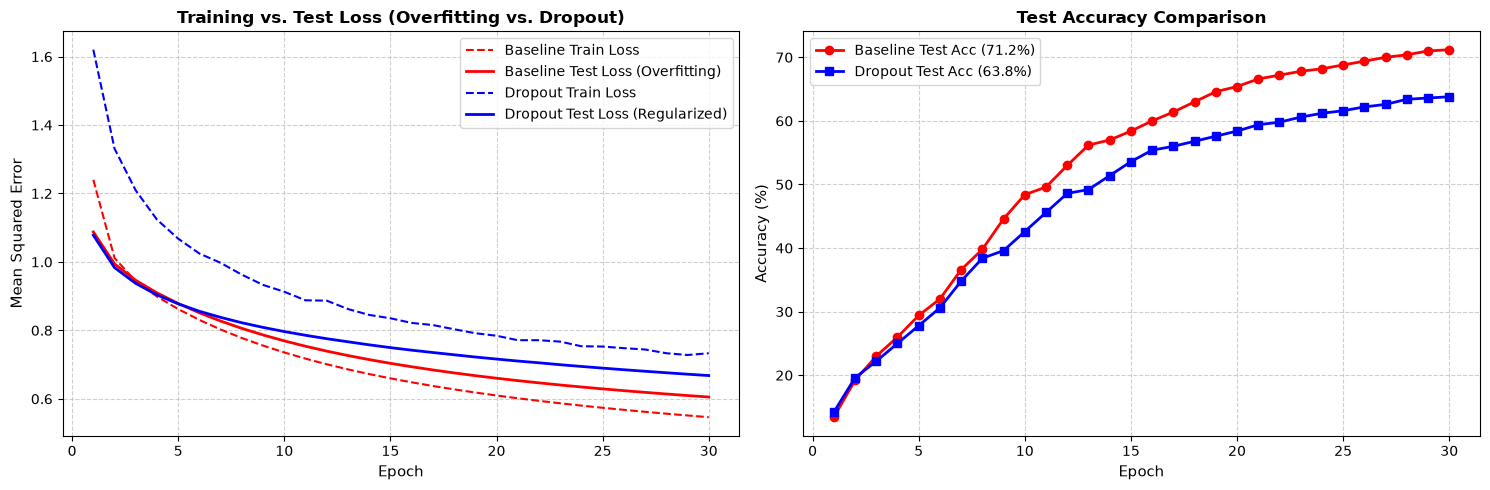

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss curves
axes[0].plot(range(1, EPOCHS + 1), base_train_loss, 'r--', label='Baseline Train Loss')
axes[0].plot(range(1, EPOCHS + 1), base_test_loss, 'r-', linewidth=2, label='Baseline Test Loss (Overfitting)')
axes[0].plot(range(1, EPOCHS + 1), drop_train_loss, 'b--', label='Dropout Train Loss')
axes[0].plot(range(1, EPOCHS + 1), drop_test_loss, 'b-', linewidth=2, label='Dropout Test Loss (Regularized)')
axes[0].set_title("Training vs. Test Loss (Overfitting vs. Dropout)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Mean Squared Error", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=10)

# Plot 2: Test Accuracy
axes[1].plot(range(1, EPOCHS + 1), base_test_acc, 'r-o', linewidth=2, label=f'Baseline Test Acc ({base_test_acc[-1]:.1f}%)')
axes[1].plot(range(1, EPOCHS + 1), drop_test_acc, 'b-s', linewidth=2, label=f'Dropout Test Acc ({drop_test_acc[-1]:.1f}%)')
axes[1].set_title("Test Accuracy Comparison", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy (%)", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 4. Key Takeaway & Summary

1. **The Origin of Overfitting:**
   Deep architectures have thousands of degrees of freedom. Without regularization, neurons co-adapt to memorize sample noise rather than invariant features, causing test loss to diverge.
2. **Dropout as an Implicit Ensemble:**
   By randomly muting $50\%$ of hidden neurons with an inverted Bernoulli mask ($mask \times 2.0$), dropout forces each neuron to develop robust, independent representations, successfully narrowing the generalization gap.
3. **Mini-Batching Accelerates Convergence:**
   Mini-batching ($B = 100$) leverages SIMD matrix operations while delivering smooth, variance-reduced gradient approximations, combining the computational speed of vectorization with the generalization benefits of stochastic updates.